In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
id2class = {idx: c for c, idx in class2id.items()}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset_concepts, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
dataset_classes = prepare_class_concept_dataset(class_concept_matrix, class2id)

### Train

In [4]:
from src.BOX.model import BoxHierarchyModel, BoxHierarchyModelJoint
from src.BOX.train import train_box, train_box_joint
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=16)
box_model_joint = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes), dim=16)
optimizer = Adam(box_model.parameters(), lr=LR)
optimizer_joint = Adam(box_model_joint.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [5]:
train_box(box_model, optimizer, criterion, dataset_concepts, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 2.8304
Epoca [10/100] | Loss: 0.4594
Epoca [20/100] | Loss: 0.2185
Epoca [30/100] | Loss: 0.0959
Epoca [40/100] | Loss: 0.0674
Epoca [50/100] | Loss: 0.0442
Epoca [60/100] | Loss: 0.0081
Epoca [70/100] | Loss: 0.0040
Epoca [80/100] | Loss: 0.0016
Epoca [90/100] | Loss: 0.0012
Epoca [100/100] | Loss: 0.0010

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0051
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


In [6]:
train_box_joint(
    box_model_joint, 
    optimizer_joint, 
    criterion, 
    dataset_concepts, 
    dataset_classes, 
    concept2id, 
    class2id, 
    id2concept,
    id2class
)

Concetti: 50 | Classi: 50
Supervisioni Concetti: 583 | Supervisioni Classi: 2500

Inizio Addestramento Congiunto...
Epoca [1/100] | L_Tot: 8.5675 (L_Conc: 2.6916, L_Cls: 5.8759)
Epoca [10/100] | L_Tot: 0.9018 (L_Conc: 0.3117, L_Cls: 0.5901)
Epoca [20/100] | L_Tot: 0.5385 (L_Conc: 0.1564, L_Cls: 0.3821)
Epoca [30/100] | L_Tot: 0.3269 (L_Conc: 0.0851, L_Cls: 0.2418)
Epoca [40/100] | L_Tot: 0.2296 (L_Conc: 0.0564, L_Cls: 0.1732)
Epoca [50/100] | L_Tot: 0.1718 (L_Conc: 0.0400, L_Cls: 0.1318)
Epoca [60/100] | L_Tot: 0.1360 (L_Conc: 0.0322, L_Cls: 0.1038)
Epoca [70/100] | L_Tot: 0.1106 (L_Conc: 0.0276, L_Cls: 0.0831)
Epoca [80/100] | L_Tot: 0.0924 (L_Conc: 0.0243, L_Cls: 0.0681)
Epoca [90/100] | L_Tot: 0.0790 (L_Conc: 0.0223, L_Cls: 0.0567)
Epoca [100/100] | L_Tot: 0.0683 (L_Conc: 0.0203, L_Cls: 0.0480)

Addestramento completato!

Verifica di alcune assegnazioni Classe-Concetto:
Classe: antelope | Concetto: black
 - P_teorica: 0.0 -> P_predetta: 0.2552
Classe: hamster | Concetto: black
 - P_

### Visualization

In [ ]:
from src.BOX.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

In [ ]:
visualize_heatmap_compare(box_model, dataset_concepts, concept2id, id2concept)

In [ ]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

In [ ]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Visualization JOINT

In [7]:

from src.BOX.visualization import visualize_box_pair, visualize_class_concept_heatmap, visualize_joint_boxes_2d

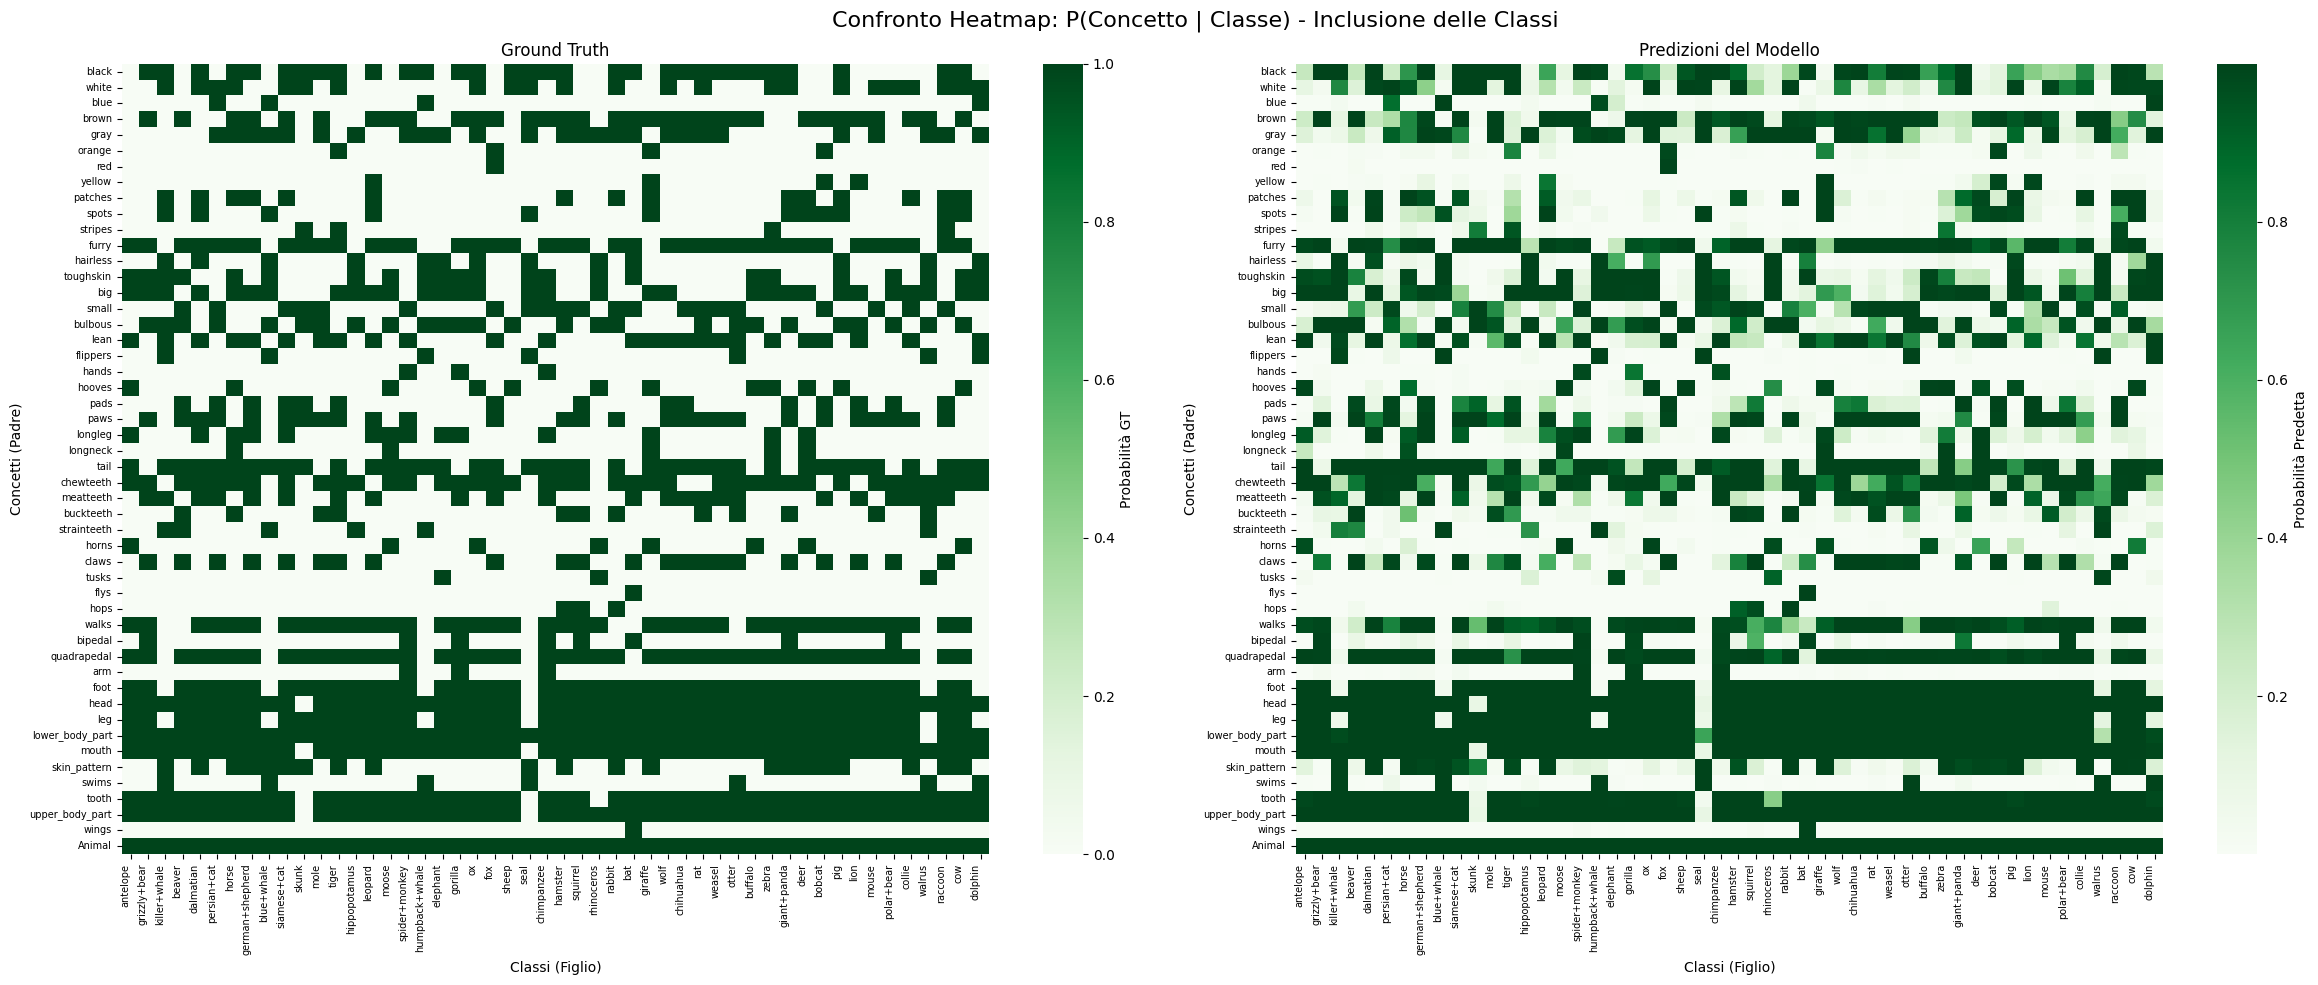

In [8]:
visualize_class_concept_heatmap(box_model_joint, dataset_classes, id2concept, id2class)

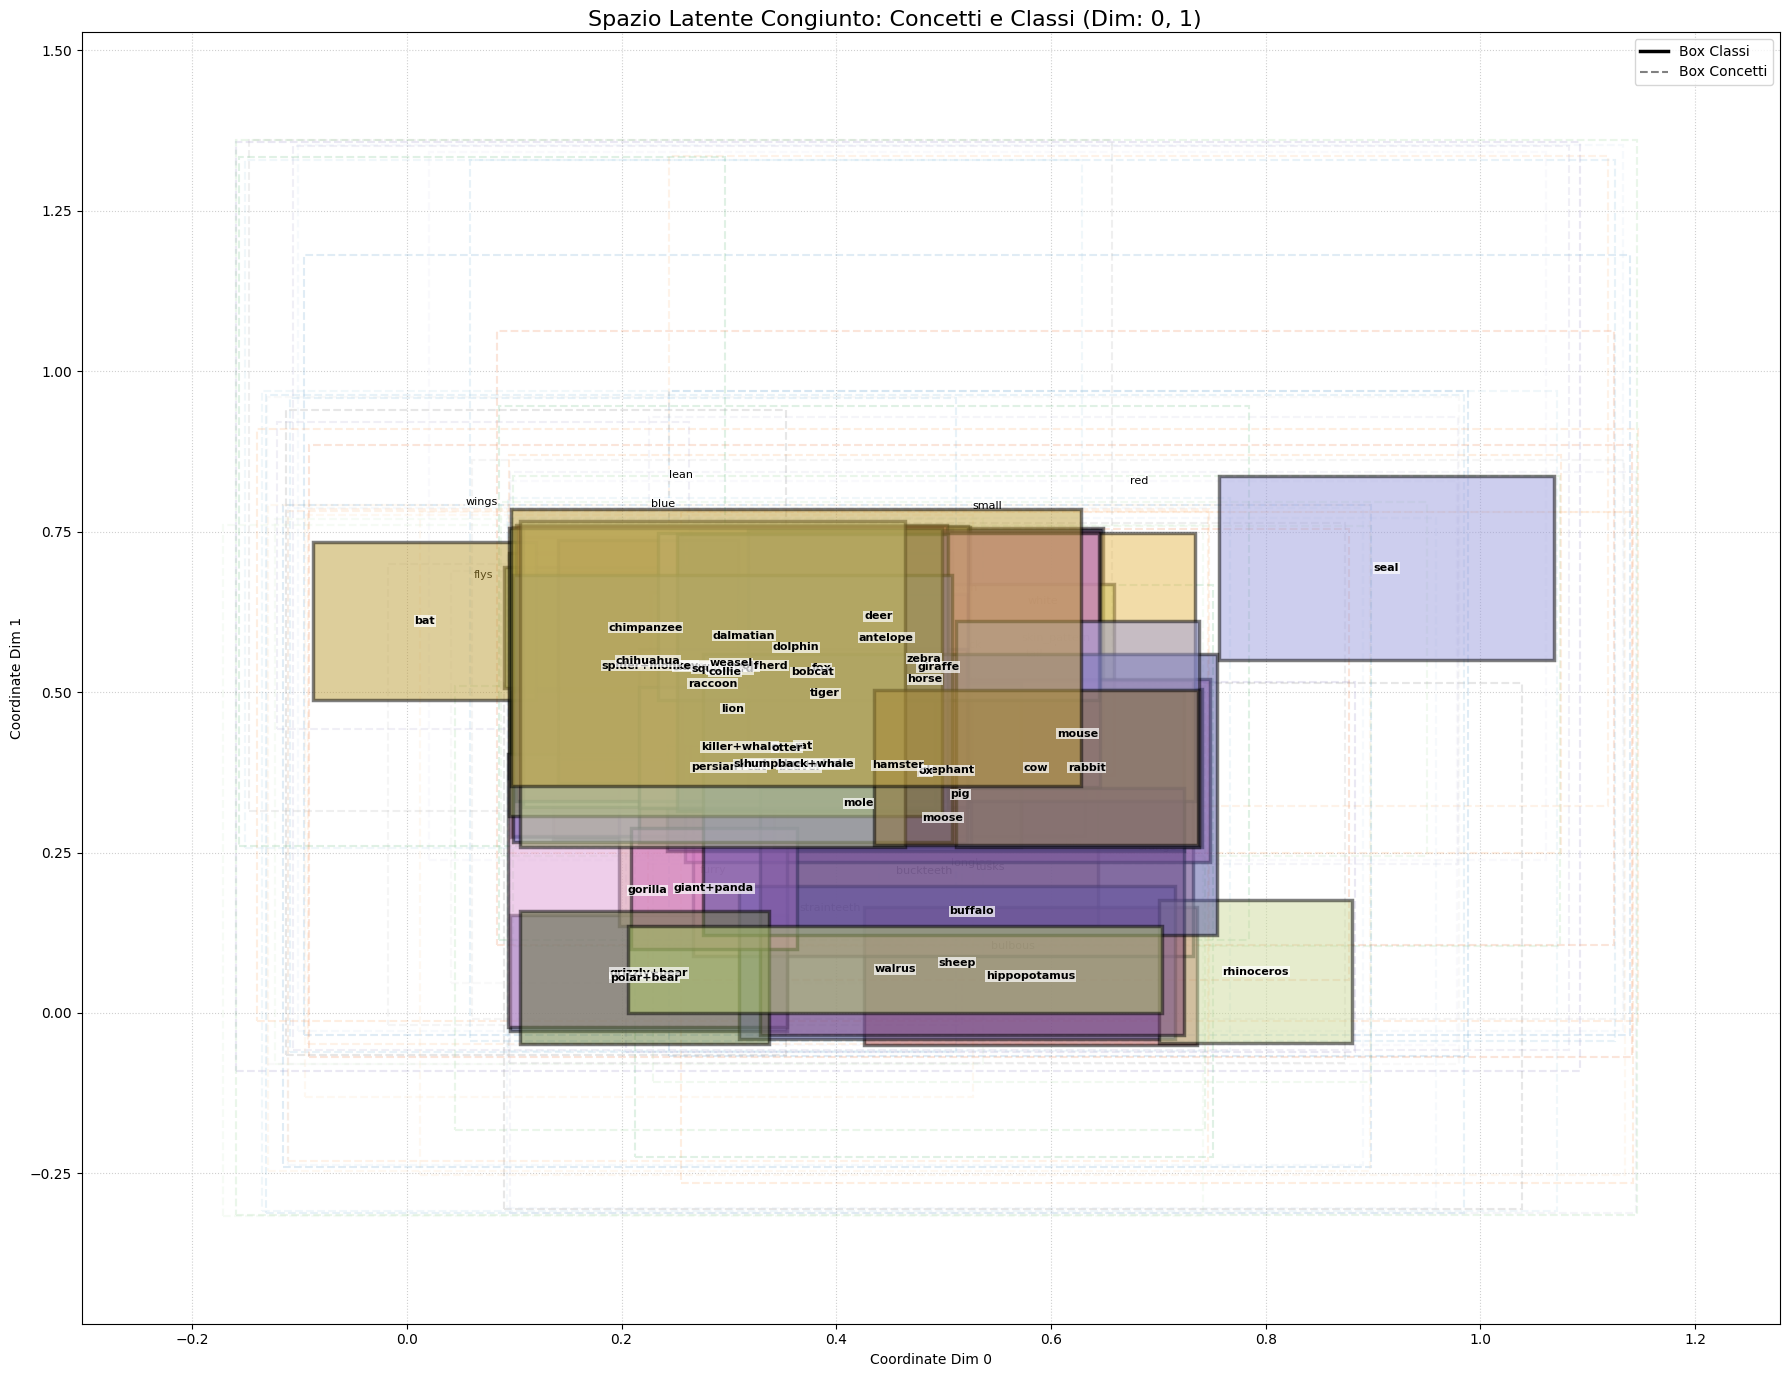

In [9]:
visualize_joint_boxes_2d(box_model_joint, id2concept, id2class)

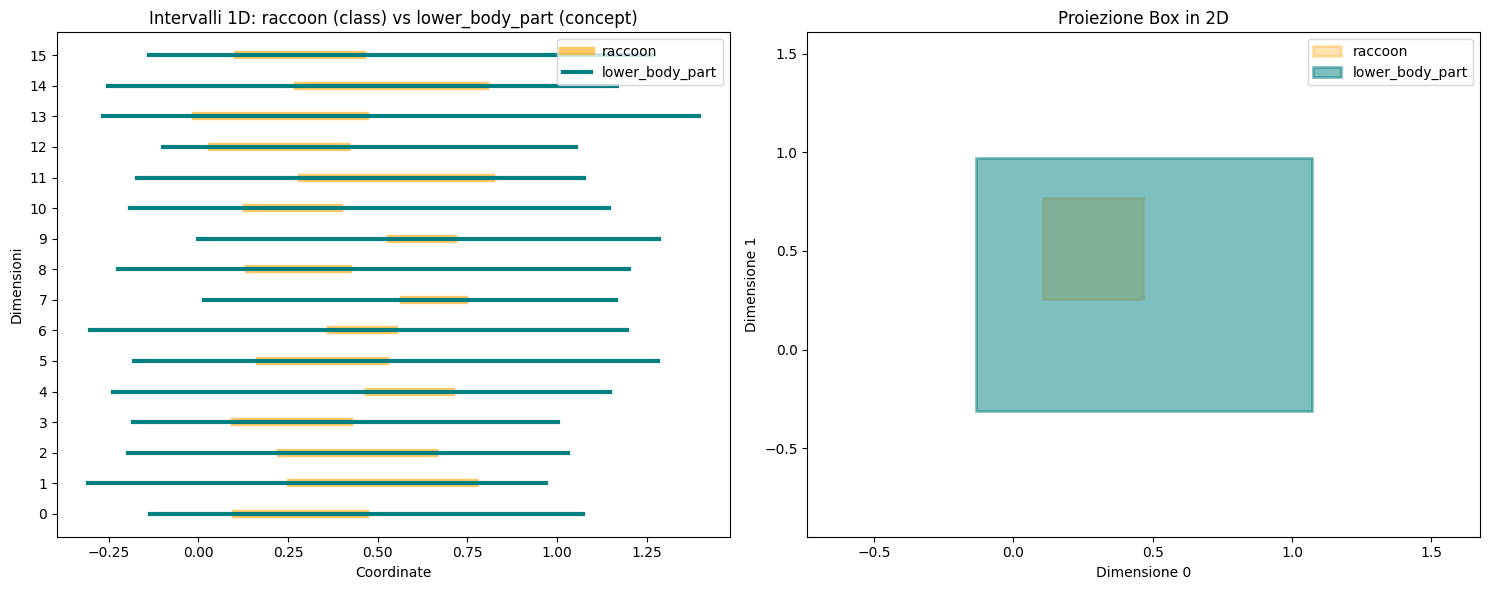

In [10]:
visualize_box_pair(box_model_joint, name_i="raccoon", name_j="lower_body_part", type_i="class", type_j="concept", dict2id_i=class2id, dict2id_j=concept2id)

### Save boxes

In [11]:
import torch
torch.save(box_model.state_dict(), "../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth")
torch.save(box_model_joint.state_dict(), "../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth")